In [30]:
# Importing everything
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [31]:
def create_bell_pair():
    """
    Returns:
        QuantumCircuit: Circuit that produces a Bell pair
    """
    qc = QuantumCircuit(2)
    qc.h(1)
    qc.cx(1, 0)
    return qc

In [32]:
def encode_message(qc, qubit, msg):
    """Encodes a two-bit message on qc using the superdense coding protocol
    Args:
        qc (QuantumCircuit): Circuit to encode message on
        qubit (int): Which qubit to add the gate to
        msg (str): Two-bit message to send
    Returns:
        QuantumCircuit: Circuit that, when decoded, will produce msg
    Raises:
        ValueError if msg is wrong length or contains invalid characters
    """
    if len(msg) != 2 or not set(msg).issubset({"0","1"}):
        raise ValueError(f"message '{msg}' is invalid")
    if msg[1] == "1":
        qc.x(qubit)
    if msg[0] == "1":
        qc.z(qubit)
    return qc

In [33]:
def decode_message(qc):
    qc.cx(1, 0)
    qc.h(1)
    return qc

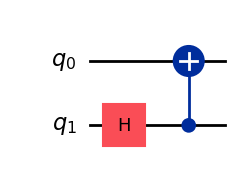

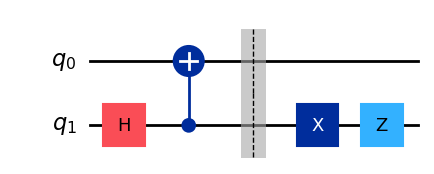

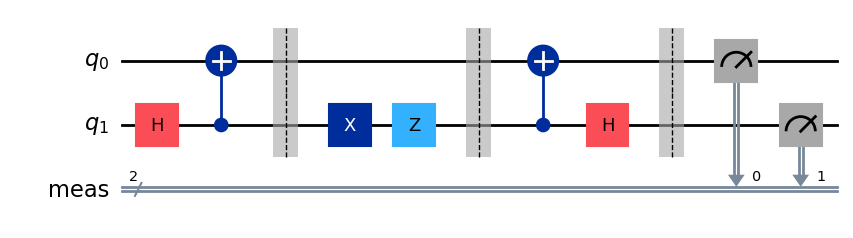

In [34]:
# Charlie creates the entangled pair between Alice and Bob
qc = create_bell_pair()
display(qc.draw(output='mpl'))
# We'll add a barrier for visual separation
qc.barrier()

# At this point, qubit 0 goes to Alice and qubit 1 goes to Bob

# Next, Alice encodes her message onto qubit 1. In this case,
# we want to send the message '10'. You can try changing this
# value and see how it affects the circuit
message = '11'
qc = encode_message(qc, 1, message)
display(qc.draw(output='mpl'))
qc.barrier()
# Alice then sends her qubit to Bob.

# After receiving qubit 0, Bob applies the recovery protocol:
qc = decode_message(qc)

# Finally, Bob measures his qubits to read Alice's message
qc.measure_all()
# Draw our output
display(qc.draw(output='mpl'))

Result(backend_name='aer_simulator', backend_version='0.17.1', qobj_id='', job_id='a66f6fed-e89a-4481-8b50-3c597418782f', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x3': 1024}), header=QobjExperimentHeader(creg_sizes=[['meas', 2]], global_phase=0.0, memory_slots=2, n_qubits=2, name='circuit-172', qreg_sizes=[['q', 2]], metadata={}), status=DONE, seed_simulator=2802567149, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0040738, 'sample_measure_time': 0.0006786, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 32454, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 28, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.0040738)], date=2025-11-27T21:42:50

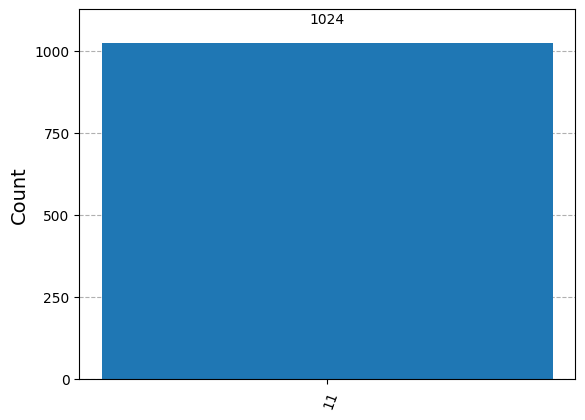

In [36]:
aer_sim = Aer.get_backend('aer_simulator')
result = aer_sim.run(qc).result()
print(result)
counts = result.get_counts(qc)
print(counts)
plot_histogram(counts)